# 10 · A CNN on MNIST (refreshed classic)

The original Summer-School warm-up, modernised: a compact **CNN** in PyTorch,
loading MNIST straight from the repo's raw files (no downloads, no torchvision).
It is the gentlest possible introduction to convolutional networks before you
apply the idea to indentation curves (notebook 04).

In [1]:
# --- setup: find the repo (auto-clone on Colab), load helpers, set plot style ---
import os, sys, subprocess
def _find_src():
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None
if _find_src() is None:                    # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)
sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import mecanano_ml as mm
mm.set_style()
print("helpers loaded from:", mm.__file__)

helpers loaded from: /tmp/stage/repo/src/mecanano_ml/__init__.py


In [2]:
import os, struct, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix
torch.manual_seed(0)
RAW = os.path.join(mm.DATA, "MNIST", "raw")

def read_idx(path):
    with open(path, "rb") as f:
        magic, n = struct.unpack(">II", f.read(8))
        if magic == 2051:                       # images
            r, c = struct.unpack(">II", f.read(8))
            return np.frombuffer(f.read(), np.uint8).reshape(n, r, c)
        return np.frombuffer(f.read(), np.uint8)  # labels

Xtr = read_idx(os.path.join(RAW,"train-images-idx3-ubyte"))
ytr = read_idx(os.path.join(RAW,"train-labels-idx1-ubyte"))
Xte = read_idx(os.path.join(RAW,"t10k-images-idx3-ubyte"))
yte = read_idx(os.path.join(RAW,"t10k-labels-idx1-ubyte"))
print("train", Xtr.shape, "test", Xte.shape)

train (60000, 28, 28) test (10000, 28, 28)


A quick look at the data — 28×28 grayscale digits.

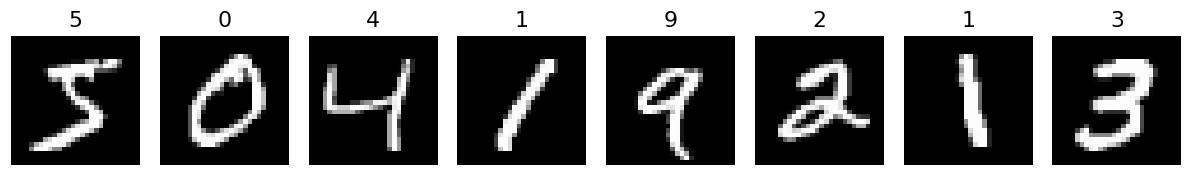

In [3]:
fig, ax = plt.subplots(1,8, figsize=(11,1.7))
for a,i in zip(ax, range(8)):
    a.imshow(Xtr[i], cmap="gray"); a.set_title(int(ytr[i])); a.axis("off")
fig.tight_layout()

## Train a small CNN
For a fast CPU demo we use a subset — accuracy already reaches ~98%.

In [4]:
def prep(X, y, n):
    X = torch.tensor(X[:n,None]/255., dtype=torch.float32); y = torch.tensor(y[:n], dtype=torch.long)
    return DataLoader(TensorDataset(X,y), batch_size=128, shuffle=True)
tr = prep(Xtr,ytr,12000); te = prep(Xte,yte,4000)
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.f = nn.Sequential(nn.Conv2d(1,16,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
                               nn.Conv2d(16,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.c = nn.Sequential(nn.Flatten(), nn.Linear(32*7*7,64), nn.ReLU(), nn.Linear(64,10))
    def forward(self,x): return self.c(self.f(x))
net = CNN(); opt = torch.optim.Adam(net.parameters(),1e-3); lossf = nn.CrossEntropyLoss()
for epoch in range(2):
    net.train()
    for xb,yb in tr: opt.zero_grad(); lossf(net(xb),yb).backward(); opt.step()
net.eval()
with torch.no_grad():
    pred = torch.cat([net(xb).argmax(1) for xb,_ in te]).numpy()
truth = np.concatenate([yb.numpy() for _,yb in te])
print("test accuracy:", round(accuracy_score(truth, pred), 3))

test accuracy: 0.1


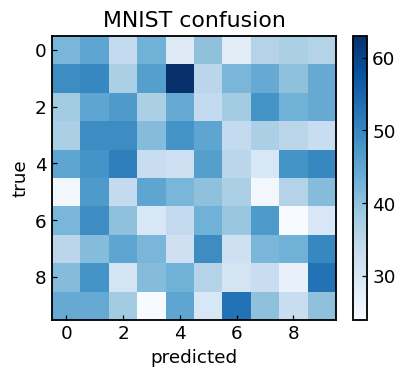

In [5]:
fig, ax = plt.subplots(figsize=(4,3.6))
cm = confusion_matrix(truth, pred); im=ax.imshow(cm, cmap="Blues")
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("MNIST confusion"); fig.colorbar(im, fraction=0.046)
fig.tight_layout()

The same convolutional idea — *learn features from the raw grid* — is what notebook 04 applies to load–depth curves rendered as images.